In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


In [2]:
raw_path = "flights.csv"   # update path if needed
df = pd.read_csv(raw_path)

df.head()


,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,name
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00,JetBlue Airways
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.


In [3]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

print("\nMissing values per column:")
df.isna().sum().sort_values(ascending=False)


Shape: (336776, 21)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 21 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              336776 non-null  int64  
 1   year            336776 non-null  int64  
 2   month           336776 non-null  int64  
 3   day             336776 non-null  int64  
 4   dep_time        328521 non-null  float64
 5   sched_dep_time  336776 non-null  int64  
 6   dep_delay       328521 non-null  float64
 7   arr_time        328063 non-null  float64
 8   sched_arr_time  336776 non-null  int64  
 9   arr_delay       327346 non-null  float64
 10  carrier         336776 non-null  object 
 11  flight          336776 non-null  int64  
 12  tailnum         334264 non-null  object 
 13  origin          336776 non-null  object 
 14  dest            336776 non-null  object 
 15  air_time        327346 non-null  float64
 16  distance        336776 non-nu

arr_delay         9430
air_time          9430
arr_time          8713
dep_time          8255
dep_delay         8255
tailnum           2512
id                   0
origin               0
time_hour            0
minute               0
hour                 0
distance             0
dest                 0
carrier              0
flight               0
year                 0
sched_arr_time       0
sched_dep_time       0
day                  0
month                0
name                 0
dtype: int64

In [4]:
df["cancelled"] = df["dep_time"].isna() | df["arr_time"].isna()

print(df["cancelled"].value_counts())


cancelled
False    328063
True       8713
Name: count, dtype: int64


In [5]:
# keep only flights that are not cancelled
flights = df[~df["cancelled"]].copy()

print("After removing cancelled flights:", flights.shape)
flights.isna().sum().sort_values(ascending=False)


After removing cancelled flights: (328063, 22)


air_time          717
arr_delay         717
id                  0
tailnum             0
name                0
time_hour           0
minute              0
hour                0
distance            0
dest                0
origin              0
flight              0
year                0
carrier             0
sched_arr_time      0
arr_time            0
dep_delay           0
sched_dep_time      0
dep_time            0
day                 0
month               0
cancelled           0
dtype: int64

In [6]:
flights = flights.dropna(subset=["arr_delay", "air_time"])

print("After dropping incomplete delay/air_time rows:", flights.shape)
flights.isna().sum().sort_values(ascending=False)


After dropping incomplete delay/air_time rows: (327346, 22)


id                0
year              0
name              0
time_hour         0
minute            0
hour              0
distance          0
air_time          0
dest              0
origin            0
tailnum           0
flight            0
carrier           0
arr_delay         0
sched_arr_time    0
arr_time          0
dep_delay         0
sched_dep_time    0
dep_time          0
day               0
month             0
cancelled         0
dtype: int64

In [7]:
# convert time_hour to proper datetime
flights["time_hour"] = pd.to_datetime(flights["time_hour"])

# ensure integer columns are int (they already should be, but this is explicit)
int_cols = ["id", "year", "month", "day",
            "sched_dep_time", "sched_arr_time",
            "flight", "distance", "hour", "minute"]

for c in int_cols:
    flights[c] = flights[c].astype(int)

flights.dtypes


id                         int32
year                       int32
month                      int32
day                        int32
dep_time                 float64
sched_dep_time             int32
dep_delay                float64
arr_time                 float64
sched_arr_time             int32
arr_delay                float64
carrier                   object
flight                     int32
tailnum                   object
origin                    object
dest                      object
air_time                 float64
distance                   int32
hour                       int32
minute                     int32
time_hour         datetime64[ns]
name                      object
cancelled                   bool
dtype: object

In [8]:
# base date
dep_date = pd.to_datetime(flights[["year", "month", "day"]])

# dep_time as integer hhmm
dep_time_int = flights["dep_time"].astype(int)

dep_hour = dep_time_int // 100
dep_min = dep_time_int % 100

flights["dep_datetime"] = dep_date + pd.to_timedelta(dep_hour, unit="h") + pd.to_timedelta(dep_min, unit="m")

flights[["dep_time", "dep_datetime"]].head()


,dep_time,dep_datetime
0,517.0,2013-01-01 05:17:00
1,533.0,2013-01-01 05:33:00
2,542.0,2013-01-01 05:42:00
3,544.0,2013-01-01 05:44:00
4,554.0,2013-01-01 05:54:00


In [9]:
cols_order = [
    "id",
    "dep_datetime",
    "year", "month", "day",
    "carrier", "flight", "tailnum",
    "origin", "dest", "distance",
    "dep_time", "sched_dep_time", "dep_delay",
    "arr_time", "sched_arr_time", "arr_delay",
    "air_time",
    "hour", "minute",
    "time_hour",
    "name"
]

# keep only the columns that actually exist in flights
cols_order = [c for c in cols_order if c in flights.columns]

flights = flights[cols_order]

flights.head()


,id,dep_datetime,year,month,day,carrier,flight,tailnum,origin,dest,distance,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,air_time,hour,minute,time_hour,name
0,0,2013-01-01 05:17:00,2013,1,1,UA,1545,N14228,EWR,IAH,1400,517.0,515,2.0,830.0,819,11.0,227.0,5,15,2013-01-01 05:00:00,United Air Lines Inc.
1,1,2013-01-01 05:33:00,2013,1,1,UA,1714,N24211,LGA,IAH,1416,533.0,529,4.0,850.0,830,20.0,227.0,5,29,2013-01-01 05:00:00,United Air Lines Inc.
2,2,2013-01-01 05:42:00,2013,1,1,AA,1141,N619AA,JFK,MIA,1089,542.0,540,2.0,923.0,850,33.0,160.0,5,40,2013-01-01 05:00:00,American Airlines Inc.
3,3,2013-01-01 05:44:00,2013,1,1,B6,725,N804JB,JFK,BQN,1576,544.0,545,-1.0,1004.0,1022,-18.0,183.0,5,45,2013-01-01 05:00:00,JetBlue Airways
4,4,2013-01-01 05:54:00,2013,1,1,DL,461,N668DN,LGA,ATL,762,554.0,600,-6.0,812.0,837,-25.0,116.0,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.


In [10]:
clean_path = "flights_clean.csv"
flights.to_csv(clean_path, index=False)
clean_path


'flights_clean.csv'

In [11]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

flights = pd.read_csv("flights_clean.csv", parse_dates=["dep_datetime"])

flights.head()


,id,dep_datetime,year,month,day,carrier,flight,tailnum,origin,dest,distance,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,air_time,hour,minute,time_hour,name
0,0,2013-01-01 05:17:00,2013,1,1,UA,1545,N14228,EWR,IAH,1400,517.0,515,2.0,830.0,819,11.0,227.0,5,15,2013-01-01 05:00:00,United Air Lines Inc.
1,1,2013-01-01 05:33:00,2013,1,1,UA,1714,N24211,LGA,IAH,1416,533.0,529,4.0,850.0,830,20.0,227.0,5,29,2013-01-01 05:00:00,United Air Lines Inc.
2,2,2013-01-01 05:42:00,2013,1,1,AA,1141,N619AA,JFK,MIA,1089,542.0,540,2.0,923.0,850,33.0,160.0,5,40,2013-01-01 05:00:00,American Airlines Inc.
3,3,2013-01-01 05:44:00,2013,1,1,B6,725,N804JB,JFK,BQN,1576,544.0,545,-1.0,1004.0,1022,-18.0,183.0,5,45,2013-01-01 05:00:00,JetBlue Airways
4,4,2013-01-01 05:54:00,2013,1,1,DL,461,N668DN,LGA,ATL,762,554.0,600,-6.0,812.0,837,-25.0,116.0,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.


In [12]:
print("Shape:", flights.shape)
print("\nInfo:")
flights.info()

print("\nMissing values per column:")
print(flights.isna().sum().sort_values(ascending=False))


Shape: (327346, 22)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327346 entries, 0 to 327345
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              327346 non-null  int64         
 1   dep_datetime    327346 non-null  datetime64[ns]
 2   year            327346 non-null  int64         
 3   month           327346 non-null  int64         
 4   day             327346 non-null  int64         
 5   carrier         327346 non-null  object        
 6   flight          327346 non-null  int64         
 7   tailnum         327346 non-null  object        
 8   origin          327346 non-null  object        
 9   dest            327346 non-null  object        
 10  distance        327346 non-null  int64         
 11  dep_time        327346 non-null  float64       
 12  sched_dep_time  327346 non-null  int64         
 13  dep_delay       327346 non-null  float64       
 14  arr_time 

In [13]:
# Delay distributions
print("Dep delay summary:")
print(flights["dep_delay"].describe())

print("\nArr delay summary:")
print(flights["arr_delay"].describe())

# Any negative air_time or distance?
print("\nNegative air_time count:", (flights["air_time"] < 0).sum())
print("Zero/negative distance count:", (flights["distance"] <= 0).sum())


Dep delay summary:
count    327346.000000
mean         12.555156
std          40.065688
min         -43.000000
25%          -5.000000
50%          -2.000000
75%          11.000000
max        1301.000000
Name: dep_delay, dtype: float64

Arr delay summary:
count    327346.000000
mean          6.895377
std          44.633292
min         -86.000000
25%         -17.000000
50%          -5.000000
75%          14.000000
max        1272.000000
Name: arr_delay, dtype: float64

Negative air_time count: 0
Zero/negative distance count: 0


In [14]:
# Binary indicator: was the flight late on arrival? (arr_delay > 0)
flights["late_arrival"] = (flights["arr_delay"] > 0).astype(int)

# Departure date (no time)
flights["dep_date"] = flights["dep_datetime"].dt.date

# Day of week
flights["dep_dow"] = flights["dep_datetime"].dt.day_name()

flights[["dep_datetime", "dep_date", "dep_dow", "arr_delay", "late_arrival"]].head()


,dep_datetime,dep_date,dep_dow,arr_delay,late_arrival
0,2013-01-01 05:17:00,2013-01-01,Tuesday,11.0,1
1,2013-01-01 05:33:00,2013-01-01,Tuesday,20.0,1
2,2013-01-01 05:42:00,2013-01-01,Tuesday,33.0,1
3,2013-01-01 05:44:00,2013-01-01,Tuesday,-18.0,0
4,2013-01-01 05:54:00,2013-01-01,Tuesday,-25.0,0


In [15]:
# 1) Carrier-level stats
carrier_stats = (
    flights
    .groupby("carrier")
    .agg(
        n_flights=("id", "count"),
        avg_arr_delay=("arr_delay", "mean"),
        pct_late=("late_arrival", "mean")
    )
    .sort_values("avg_arr_delay")
)

carrier_stats


,n_flights,avg_arr_delay,pct_late
carrier,,,
AS,709,-9.930889,0.266573
HA,342,-6.915205,0.283626
AA,31947,0.364291,0.335118
DL,47658,1.644341,0.344391
VX,5116,1.764464,0.341282
US,19831,2.129595,0.370581
UA,57782,3.558011,0.384583
9E,17294,7.379669,0.383775
B6,54049,9.457973,0.436807


In [16]:
# 2) Route-level stats (origin–dest)
route_stats = (
    flights
    .groupby(["origin", "dest"])
    .agg(
        n_flights=("id", "count"),
        avg_arr_delay=("arr_delay", "mean")
    )
    .query("n_flights >= 100")  # optional filter to avoid tiny routes
    .sort_values("avg_arr_delay", ascending=False)
)

route_stats.head(10)


n_flights  avg_arr_delay
origin dest                          
EWR    TYS         313      41.150160
       TUL         294      33.659864
       OKC         315      30.619048
       RIC        1615      25.820433
       MKE        1058      24.003781
       DSM         390      23.548718
       MSN         345      23.197101
       PWM         730      23.005479
JFK    CMH         705      22.920567
EWR    DCA        1567      21.313976

In [17]:
# 3) Daily average delay
daily_delay = (
    flights
    .groupby("dep_date")
    .agg(avg_arr_delay=("arr_delay", "mean"))
    .reset_index()
)

daily_delay.head()


,dep_date,avg_arr_delay
0,2013-01-01,12.651023
1,2013-01-02,12.692888
2,2013-01-03,5.733333
3,2013-01-04,-1.932819
4,2013-01-05,-1.525802


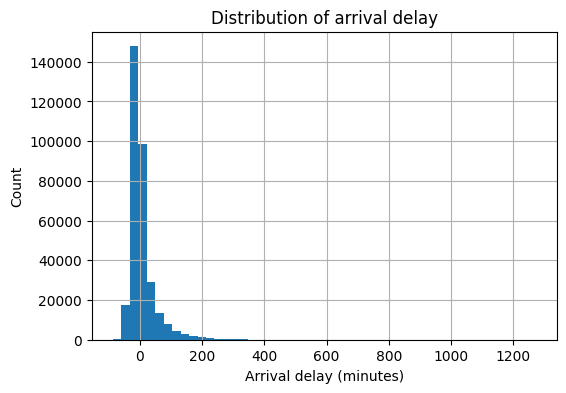

In [18]:
import matplotlib.pyplot as plt

# Histogram of arrival delay
plt.figure(figsize=(6,4))
flights["arr_delay"].hist(bins=50)
plt.xlabel("Arrival delay (minutes)")
plt.ylabel("Count")
plt.title("Distribution of arrival delay")
plt.show()


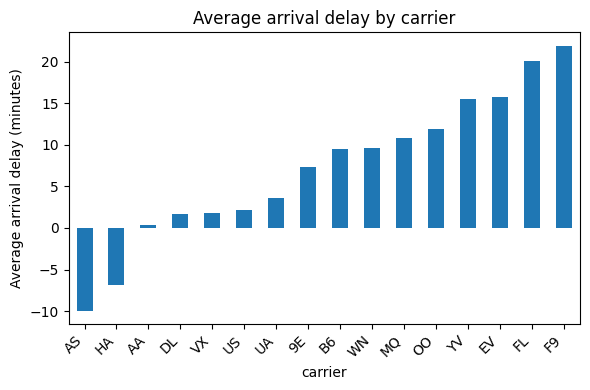

In [19]:
# Average arrival delay by carrier
plt.figure(figsize=(6,4))
carrier_stats["avg_arr_delay"].plot(kind="bar")
plt.ylabel("Average arrival delay (minutes)")
plt.title("Average arrival delay by carrier")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [20]:
import pandas as pd
df = pd.read_csv("flights_clean.csv")
print(df.columns)


Index(['id', 'dep_datetime', 'year', 'month', 'day', 'carrier', 'flight', 'tailnum', 'origin', 'dest', 'distance', 'dep_time',
       'sched_dep_time', 'dep_delay', 'arr_time', 'sched_arr_time', 'arr_delay', 'air_time', 'hour', 'minute', 'time_hour', 'name'],
      dtype='object')
